# Conditional distributions & the Schur complement

Two faces of the same Gaussian:

- **Notebook 0.6** showed how to absorb evidence *sequentially* — each new observation is one natural-parameter addition.
- **This notebook** shows the *static* version. Stack everything you know and don't know into one big joint Gaussian, then read off the conditional in closed form.

For Gaussians these two views are mathematically identical. Operationally they're complementary:

| View | When to use | API |
|------|-------------|-----|
| Sequential ([0.6](bayesian_updates.ipynb)) | Streaming data, online filtering, Kalman recursions | natural-form addition + `to_expectation` |
| Conditioning (this notebook) | All data in hand, GP prediction, joint surveys | `gaussx.conditional`, `schur_complement` |

The single algebraic object that makes the conditioning view work is the **Schur complement**. We

1. recall the joint-partition formulae from [0.1](multivariate_gaussian.ipynb#eq:mvn-partition);
2. tour `gaussx.conditional`, `gaussx.schur_complement`, and `gaussx.conditional_variance`;
3. verify GP regression matches both the natural-form recipe from [](bayesian_updates.ipynb#eq:gp-as-bayes) and the joint-conditioning recipe;
4. close with `gaussx.cov_transform` — the *forward* counterpart, propagating uncertainty through a linear map.

Prerequisites: [0.1 — Multivariate Gaussian](multivariate_gaussian.ipynb) (especially [](multivariate_gaussian.ipynb#eq:cond-mean) and [](multivariate_gaussian.ipynb#eq:cond-cov)), [0.6 — Bayesian updates](bayesian_updates.ipynb).

In [1]:
from __future__ import annotations

import warnings
warnings.filterwarnings("ignore", message=r".*IProgress.*")

import einx
import jax
import jax.numpy as jnp
import lineax as lx
import matplotlib.pyplot as plt
import numpy as np
import gaussx
from gaussx import (
    conditional,
    conditional_variance,
    cov_transform,
    dist_kl_divergence,
    schur_complement,
    solve,
)

jax.config.update("jax_enable_x64", True)
KEY = jax.random.PRNGKey(42)
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.grid": True,
    "axes.grid.which": "both",
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "grid.alpha": 0.3,
})


def psd_op(M):
    return lx.MatrixLinearOperator(M, lx.positive_semidefinite_tag)

## The Schur complement, in one breath

Partition a joint Gaussian per [](multivariate_gaussian.ipynb#eq:mvn-partition):

```{math}
:label: eq:joint-partition
\begin{bmatrix} x_a \\ x_b \end{bmatrix}
\sim
\mathcal{N}\!\left(
\begin{bmatrix} \mu_a \\ \mu_b \end{bmatrix},\;
\begin{bmatrix} \Sigma_{aa} & \Sigma_{ab} \\ \Sigma_{ba} & \Sigma_{bb} \end{bmatrix}
\right).
```

The conditional $x_a \mid x_b = b$ is again Gaussian, with mean and covariance from [](multivariate_gaussian.ipynb#eq:cond-mean) and [](multivariate_gaussian.ipynb#eq:cond-cov):

```{math}
:label: eq:cond-recap
\mu_{a \mid b} \;=\; \mu_a + \Sigma_{ab}\,\Sigma_{bb}^{-1}\,(b - \mu_b),
\qquad
\Sigma_{a \mid b} \;=\; \Sigma_{aa} - \Sigma_{ab}\,\Sigma_{bb}^{-1}\,\Sigma_{ba}.
```

The conditional covariance $\Sigma_{a \mid b}$ has a name independent of Gaussians: it's the **Schur complement** of the $bb$ block in the joint matrix:

```{math}
:label: eq:schur
\boxed{\;\Sigma_{aa \mid bb} \;=\; \Sigma_{aa} \;-\; \Sigma_{ab}\,\Sigma_{bb}^{-1}\,\Sigma_{ba}\;}
```

[](#eq:schur) is the algebraic backbone of every "low-rank correction to a covariance" you'll meet — GP prediction, Kalman update, sparse-GP marginals, woodbury identities, the **information form posterior covariance** [](joseph_form_update.ipynb#eq:cov-information). Each is [](#eq:schur) with different letter assignments.

:::{tip} ELI5
The Schur complement is "what's left of the $aa$-block once you condition on the $bb$-block". The $\Sigma_{ab}\Sigma_{bb}^{-1}\Sigma_{ba}$ term is the variance *explained* by knowing $x_b$; subtracting it gives the variance still *unexplained*. Mathematically it's a low-rank update of $\Sigma_{aa}$, and that's exactly how `gaussx.schur_complement` represents it.
:::

## Step 1 — Schur on a hand-picked joint

Build a 5×5 joint covariance, partition into $a = \{0, 1\}, b = \{2, 3, 4\}$, and check `gaussx.schur_complement` against an explicit `solve` + matmul. The point is to see [](#eq:schur) is *just* a low-rank correction.

In [2]:
n_a, n_b = 2, 3
n = n_a + n_b
key, k_M = jax.random.split(KEY)
M = jax.random.normal(k_M, (n, n))
Sigma = M @ M.T + 0.5 * jnp.eye(n)            # SPD

S_aa = Sigma[:n_a, :n_a]
S_ab = Sigma[:n_a, n_a:]
S_bb = Sigma[n_a:, n_a:]

# gaussx schur_complement — returns a LowRankUpdate operator (lazy, no inverse)
schur_op = schur_complement(psd_op(S_aa), S_ab, psd_op(S_bb))
print("schur op type:", type(schur_op).__name__)

# Manual Schur via solve + einx
W = jax.vmap(lambda c: solve(psd_op(S_bb), c))(S_ab)   # (n_a, n_b)  = S_bb^{-1} S_ba (rows)
S_aa_cond_manual = S_aa - einx.dot("i k, j k -> i j", S_ab, W)

S_aa_cond_op = schur_op.as_matrix()
print(f"||S_schur - S_manual||_F = {float(jnp.linalg.norm(S_aa_cond_op - S_aa_cond_manual)):.2e}")
print("Schur block:\n", np.asarray(S_aa_cond_op))

schur op type: LowRankUpdate


||S_schur - S_manual||_F = 0.00e+00
Schur block:
 [[ 1.69139834 -1.45474751]
 [-1.45474751  5.99356689]]


## Step 2 — `gaussx.conditional` — high-level API

`gaussx.conditional(loc, cov, obs_idx, obs_values)` is the all-in-one wrapper: pass the joint mean/cov, the indices that are observed, and their values. Out comes the *conditional* mean/cov over the remaining indices. Internally it does [](#eq:cond-recap) — including the Schur complement.

Below: same 5×5 joint, observe the last three coordinates at random values, condition on the first two.

In [3]:
key, k_b = jax.random.split(key)
b_obs = jax.random.normal(k_b, (n_b,))
mu_full = jnp.zeros(n)

obs_idx = jnp.arange(n_a, n, dtype=jnp.int32)   # indices [n_a, n_a+1, ..., n-1]
mu_a_cond, Sigma_a_cond_op = conditional(mu_full, psd_op(Sigma), obs_idx, b_obs)
Sigma_a_cond = Sigma_a_cond_op.as_matrix()

# Reference — direct application of the partition formula
mu_a, mu_b = mu_full[:n_a], mu_full[n_a:]
mu_a_cond_ref = mu_a + einx.dot("i k, k -> i", S_ab, solve(psd_op(S_bb), b_obs - mu_b))

print(f"||mu_cond  - mu_ref ||  = {float(jnp.linalg.norm(mu_a_cond - mu_a_cond_ref)):.2e}")
print(f"||Sig_cond - Sig_ref|| = {float(jnp.linalg.norm(Sigma_a_cond - S_aa_cond_manual)):.2e}")

||mu_cond  - mu_ref ||  = 0.00e+00
||Sig_cond - Sig_ref|| = 1.78e-15


## Step 3 — GP regression *is* conditioning a joint

The standard "GP predictive" formula

```{math}
:label: eq:gp-predictive
\mu_\star \;=\; K_{\star f}\,(K_{ff} + \sigma_n^2 I)^{-1}\,y,
\qquad
\Sigma_\star \;=\; K_{\star\star} \;-\; K_{\star f}\,(K_{ff} + \sigma_n^2 I)^{-1}\,K_{f\star}
```

is exactly [](#eq:cond-recap) applied to the augmented joint over $[y,\, f_\star]$:

```{math}
:label: eq:gp-joint
\begin{bmatrix} y \\ f_\star \end{bmatrix}
\sim
\mathcal{N}\!\left(\mathbf{0},\;
\begin{bmatrix}
K_{ff} + \sigma_n^2 I & K_{f\star} \\
K_{\star f} & K_{\star\star}
\end{bmatrix}
\right).
```

The conditional covariance $\Sigma_\star$ is the Schur complement [](#eq:schur). The same posterior emerges from the natural-form addition [](bayesian_updates.ipynb#eq:gp-as-bayes); the two recipes differ only in which block they invert.

We verify both routes agree on a 30-point sin GP.

In [4]:
def rbf(x1, x2, ls=0.8, var=1.0):
    sq = einx.subtract("i, j -> i j", x1, x2) ** 2
    return var * jnp.exp(-0.5 * sq / ls ** 2)

n_train, n_test = 30, 100
key, k_x, k_y = jax.random.split(key, 3)
x_train = jnp.sort(jax.random.uniform(k_x, (n_train,), minval=-3.0, maxval=3.0))
x_test  = jnp.linspace(-3.5, 3.5, n_test)

f_true = lambda x: jnp.sin(3.0 * x) * jnp.exp(-0.5 * x ** 2)
sigma_n = 0.2
sigma_n2 = sigma_n ** 2
y_train = f_true(x_train) + sigma_n * jax.random.normal(k_y, (n_train,))

x_all = jnp.concatenate([x_train, x_test])
K_full = rbf(x_all, x_all)
noise_blk = jnp.zeros(n_train + n_test).at[:n_train].set(sigma_n2 + 1e-6)
K_joint = K_full + jnp.diag(noise_blk)
K_joint_op = psd_op(K_joint)

mu_joint = jnp.zeros(n_train + n_test)
obs_idx  = jnp.arange(n_train, dtype=jnp.int32)

# Route A: gaussx.conditional on the augmented joint
mu_post_A, S_post_A_op = conditional(mu_joint, K_joint_op, obs_idx, y_train)

# Route B: classic GP formula via gaussx.solve
K_ff = rbf(x_train, x_train) + sigma_n2 * jnp.eye(n_train)
K_sf = rbf(x_test,  x_train)
K_ss = rbf(x_test,  x_test)
K_ff_op = psd_op(K_ff)

alpha   = solve(K_ff_op, y_train)
mu_post_B = einx.dot("i j, j -> i", K_sf, alpha)
W = jax.vmap(lambda c: solve(K_ff_op, c))(K_sf)        # (n_test, n_train)
S_post_B = K_ss - einx.dot("i k, j k -> i j", K_sf, W)

print(f"max |mu_A  - mu_B|  = {float(jnp.max(jnp.abs(mu_post_A - mu_post_B))):.2e}")
print(f"max |Sig_A - Sig_B| = {float(jnp.max(jnp.abs(S_post_A_op.as_matrix() - S_post_B))):.2e}")

# KL between the two posteriors should be zero (modulo round-off jitter).
S_A_jit = S_post_A_op.as_matrix() + 1e-6 * jnp.eye(n_test)
S_B_jit = S_post_B + 1e-6 * jnp.eye(n_test)
kl_AB = float(dist_kl_divergence(mu_post_A, psd_op(S_A_jit), mu_post_B, psd_op(S_B_jit)))
print(f"KL( route A || route B ) = {kl_AB:.2e}")

max |mu_A  - mu_B|  = 5.31e-06
max |Sig_A - Sig_B| = 1.98e-06


KL( route A || route B ) = 1.76e-09


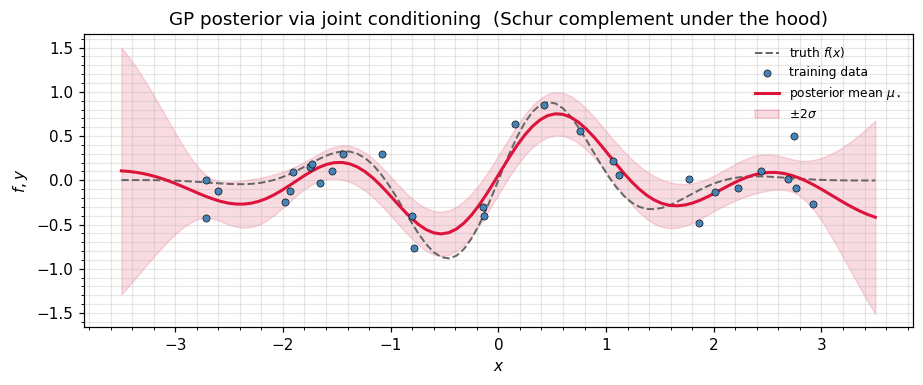

In [5]:
S_diag = jnp.maximum(jnp.diag(S_post_A_op.as_matrix()), 0.0)
sd = jnp.sqrt(S_diag)

fig, ax = plt.subplots(figsize=(8.5, 3.6))
ax.plot(np.asarray(x_test), np.asarray(f_true(x_test)), "--", color="0.4",
        lw=1.3, label=r"truth $f(x)$")
ax.scatter(np.asarray(x_train), np.asarray(y_train), s=22, color="steelblue",
           edgecolor="k", linewidth=0.4, label="training data", zorder=4)
ax.plot(np.asarray(x_test), np.asarray(mu_post_A), color="crimson", lw=2,
        label=r"posterior mean $\mu_\star$")
ax.fill_between(np.asarray(x_test),
                np.asarray(mu_post_A - 2 * sd),
                np.asarray(mu_post_A + 2 * sd),
                color="crimson", alpha=0.15, label=r"$\pm 2\sigma$")
ax.set_xlabel(r"$x$"); ax.set_ylabel(r"$f, y$")
ax.set_title(r"GP posterior via joint conditioning  (Schur complement under the hood)")
ax.legend(frameon=False, fontsize=8)
plt.tight_layout(); plt.show()

## Step 4 — Diagonal predictive variance only

Often we only need the *marginal* variance at each test point — the diagonal of $\Sigma_\star$. Forming the full $n_\star \times n_\star$ Schur block costs $O(n_\star^2 n_{\rm train})$; pulling out only the diagonal needs $O(n_\star n_{\rm train})$ via

```{math}
:label: eq:cond-var-diag
\sigma_\star^2(i) \;=\; K_{\star\star}(i, i) \;-\; \bigl(K_{\star f}\,K_{ff}^{-1}\,K_{f\star}\bigr)(i, i),
\qquad i = 1, \ldots, n_\star.
```

For the *exact* GP this is just `einx`-summing the Hadamard product `K_sf * (K_ff^{-1} K_fs)^\top`, no full Schur block needed. For the *sparse / variational* GP, `gaussx.conditional_variance(K_xx_diag, A_x, S_u)` adds the variational correction $\mathrm{diag}(A_x\,S_u\,A_x^\top)$ on top — same formula, but $S_u$ is the variational covariance over inducing points instead of the prior.

In [6]:
K_ss_diag = jnp.diag(K_ss)               # all ones for our unit-variance RBF
A_x = W                                  # K_*f K_ff^{-1}, shape (n_test, n_train)

# Diagonal predictive variance: sigma^2_*(i) = K_**(i,i) - sum_k K_*f(i,k) * A_x(i,k)
pred_var = K_ss_diag - einx.sum("i k -> i", einx.multiply("i k, i k -> i k", K_sf, A_x))

# Reference: take diag of the full Schur block.
pred_var_ref = jnp.diag(S_post_A_op.as_matrix())
print(f"max |diag(Schur) - diag-only formula| = "
      f"{float(jnp.max(jnp.abs(pred_var - pred_var_ref))):.2e}")

# For sparse / variational GPs, gaussx.conditional_variance adds the variational
# correction diag(A_x S_u A_x^T). Plugging S_u = K_ff recovers the explained-variance
# term we just subtracted, so K_ss_diag - conditional_variance(0, A_x, K_ff) matches
# the exact-GP predictive variance:
diag_AKA = conditional_variance(jnp.zeros_like(K_ss_diag), A_x, K_ff_op)
print(f"max |K_ss_diag - diag(A K_ff A^T) - exact pred_var| = "
      f"{float(jnp.max(jnp.abs((K_ss_diag - diag_AKA) - pred_var_ref))):.2e}")

max |diag(Schur) - diag-only formula| = 1.98e-06
max |K_ss_diag - diag(A K_ff A^T) - exact pred_var| = 1.98e-06


## Step 5 — Forward propagation: `cov_transform`

The Schur complement runs *backward* — we condition on observed coordinates and project the joint covariance onto the unobserved ones. The dual operation runs *forward*: given a Gaussian on $x$ and a linear map $z = J x$, the induced Gaussian on $z$ has covariance

```{math}
:label: eq:cov-transform
\Sigma_z \;=\; J\,\Sigma_x\,J^\top.
```

`gaussx.cov_transform(J, Sigma_op)` returns this as a structured operator — no matrices materialised when $\Sigma_x$ is itself structured (Kronecker, low-rank, etc.). This is the basic step in:

- linearised filters (UKF / EKF prediction step),
- linear sensitivity analysis,
- variational inference (computing $H \Sigma H^\top + R$),
- delta-method confidence intervals.

In [7]:
key, k_J = jax.random.split(key)
J = jax.random.normal(k_J, (4, n))
Sigma_z_op = cov_transform(J, psd_op(Sigma))

Sigma_z_ref = einx.dot("i a, a b, j b -> i j", J, Sigma, J)
print(f"||cov_transform - J Sigma J^T||_F = "
      f"{float(jnp.linalg.norm(Sigma_z_op.as_matrix() - Sigma_z_ref)):.2e}")

||cov_transform - J Sigma J^T||_F = 7.16e-15


## Where the Schur complement lives

| Setting | Letters | Reference |
|---------|---------|-----------|
| GP prediction | $a = \star,\ b = $ train | [](#eq:gp-predictive), this notebook |
| Kalman update covariance | $a = $ state,\ $b = $ innovation | [](joseph_form_update.ipynb#eq:cov-symmetric) |
| Information-form posterior | $\Lambda^+ = \Lambda + H^\top R^{-1} H$ | [](joseph_form_update.ipynb#eq:cov-information) |
| Sparse-GP predictive (FITC / SVGP) | $a = $ test,\ $b = $ inducing | Part 6 |
| Bayesian linear regression | $a = $ weights,\ $b = $ data | Conjugate update via [](bayesian_updates.ipynb#eq:bayes-natural) |
| Causal / structural marginals | $a = $ effect,\ $b = $ confounders | Statistics literature |
| Block matrix inversion | Inverse of partitioned matrix is built from the two Schur complements | Linear-algebra textbook identity |

:::{tip} Rule of thumb
The Schur complement is the *single* identity behind GP prediction, Kalman updates, sparse-GP marginals, and the information-form posterior. Recognise it once and you'll see the same five lines of algebra in eight different contexts.
:::

## Recap

- The Gaussian conditioning theorem [](#eq:cond-recap) reduces to the Schur complement [](#eq:schur).
- `gaussx.conditional` is the all-in-one API; `schur_complement` returns a structured `LowRankUpdate` so downstream `solve`/`logdet` can exploit the rank correction; `conditional_variance` short-cuts to the diagonal.
- GP regression with a Gaussian likelihood matches both this conditioning recipe ([](#eq:gp-predictive)) and the natural-form recipe from [](bayesian_updates.ipynb#eq:gp-as-bayes), to machine precision and in KL.
- The forward dual `cov_transform` propagates uncertainty $\Sigma_z = J \Sigma_x J^\top$ through linear maps — the building block for filter prediction steps and sensitivity analysis.

:::{seealso} Where this goes
- **0.8 — Structured MVN sampling dispatch** — once you have $\mu_\star, \Sigma_\star$, sampling from the posterior is a `root` dispatch.
- **Part 3 — Exact GPs** — every "GP posterior predictive" line is a use of `conditional` plus `conditional_variance`.
- **Part 6 — Sparse / approximate GPs** — FITC / DTC / VFE all reduce to nested Schur complements over inducing variables.
- **Part 7 — Kalman / state-space** — same identity, applied between predict and update.
:::

## References

- Rasmussen, C. E. & Williams, C. K. I. (2006). *Gaussian Processes for Machine Learning*. MIT Press, §2.2.
- Bishop, C. M. (2006). *Pattern Recognition and Machine Learning*. Springer, §2.3.1.
- Boyd, S. & Vandenberghe, L. (2004). *Convex Optimization*, Appendix A.5 (Schur complements).